<a href="https://colab.research.google.com/github/mindioanni/LandLevelTools/blob/main/Vertical_Component_error_V0_20260210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Give DOV / plumb line error ε in arcseconds (e.g., 1.5): 2
Give observed slope distance d in meters (e.g., 250): 100

Result:
|δ(ΔH)| = 0.000970 m  (0.970 mm)

Plot curves? Type 'y' to proceed, anything else to skip: y
How many curves (X)? (e.g., 5): 5
Minimum ε (arcsec): 2
Maximum ε (arcsec): 20
Minimum slope distance d (m): 10
Maximum slope distance d (m): 100
Number of distance samples (e.g., 200): 20


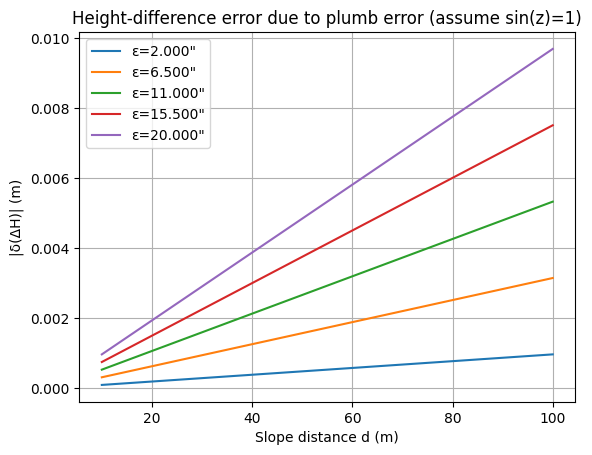

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)

def dh_error_from_plumb(d_m: float, eps_arcsec: float) -> float:
    """
    Height-difference error magnitude |δ(ΔH)| [m] due to residual plumb/tilt error.
    Assumption: sin(z)=1 (near-horizontal sight / worst-case).
    """
    eps_rad = eps_arcsec * ARCSEC_TO_RAD
    return abs(d_m * eps_rad)

# --- Part (a): single computation
eps_arcsec = float(input("Give DOV / plumb line error ε in arcseconds (e.g., 1.5): "))
d_m = float(input("Give observed slope distance d in meters (e.g., 250): "))

dh_err_m = dh_error_from_plumb(d_m=d_m, eps_arcsec=eps_arcsec)

print("\nResult:")
print(f"|δ(ΔH)| = {dh_err_m:.6f} m  ({dh_err_m*1000.0:.3f} mm)")

# --- Part (b): plot multiple curves
do_plot = input("\nPlot curves? Type 'y' to proceed, anything else to skip: ").strip().lower()
if do_plot == 'y':
    n_curves = int(input("How many curves (X)? (e.g., 5): "))
    eps_min = float(input("Minimum ε (arcsec): "))
    eps_max = float(input("Maximum ε (arcsec): "))
    d_min = float(input("Minimum slope distance d (m): "))
    d_max = float(input("Maximum slope distance d (m): "))
    n_points = int(input("Number of distance samples (e.g., 200): "))

    eps_values = np.linspace(eps_min, eps_max, n_curves)
    d_values = np.linspace(d_min, d_max, n_points)

    plt.figure()
    for eps in eps_values:
        dh_vals = dh_error_from_plumb(d_values, eps)
        plt.plot(d_values, dh_vals, label=f"ε={eps:.3f}\"")

    plt.xlabel("Slope distance d (m)")
    plt.ylabel("|δ(ΔH)| (m)")
    plt.title("Height-difference error due to plumb error (assume sin(z)=1)")
    plt.grid(True)
    plt.legend()
    plt.show()
